# **********************************************************
# Topic : Analysing the Impact of Hidden Layers on the Performance of a Multilayer Perceptron (MLP)
# DATASET: Bank Marketing Dataset
# **********************************************************


In [141]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from tensorflow import keras
from tensorflow.keras import layers

# Set random seeds to ensure reproducible results across runs

In [142]:
np.random.seed(42)
tf.random.set_seed(42)

# 1.LOADING THE DATASET

In [143]:
data = pd.read_csv("bank.csv")
data.columns = data.columns.str.strip()

print("Dataset loaded successfully")
print("Shape:", data.shape)

Dataset loaded successfully
Shape: (11162, 17)


# 2. IDENTIFY THE TARGET COLUMN


In [144]:
target = 'deposit' if 'deposit' in data.columns else 'y'

# 3. EXPLORATORY DATA ANALYSIS



# Plot the how many yes or no values are present


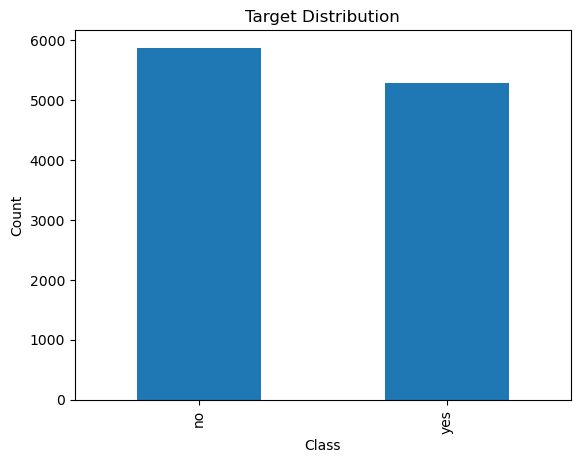

In [145]:
plt.figure()
data[target].value_counts().plot(kind='bar')
plt.title("Target Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.savefig("eda_target.png")
plt.show()

# Plot the age distribution to understand  the data spread


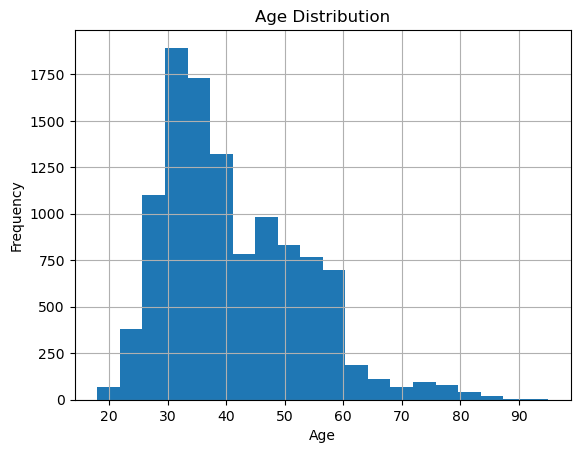

In [146]:
plt.figure()
data['age'].hist(bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.savefig("eda_age.png")
plt.show()

# 4. PREPROCESSING


In [147]:

data[target] = data[target].map({'yes': 1, 'no': 0})

# convert text columns into numbers
for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = LabelEncoder().fit_transform(data[col])

X = data.drop(target, axis=1)
y = data[target]

# split into training and test data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=5
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Preprocessing completed")

Preprocessing completed


# 5. MODEL FUNCTION


In [148]:
def build_model(layer_sizes):

    # neural network
    model = keras.Sequential([
        keras.Input(shape=(X_train.shape[1],))
    ])

    # Adding hidden layers
    for units in layer_sizes:
        model.add(layers.Dense(units, activation='relu'))
        
    # output layer
    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

# 6. MODEL CONFIGURATIONS


In [149]:
models = {
    "1_layer": [50],
    "2_layers": [70, 35],
    "3_layers": [120, 80, 40]
}

history_dict = {}
accuracy_dict = {}


# 7. TRAINING AND TESTING THE MODEL


In [ ]:
for name, config in models.items():

    print("\nTraining:", name)

    model = build_model(config)

    history = model.fit(
        X_train, y_train,
        epochs=20,
        validation_split=0.2,
        verbose=1
    )
    loss, acc = model.evaluate(X_test, y_test, verbose=0)

    history_dict[name] = history
    accuracy_dict[name] = acc

    print(f"{name} Accuracy: {acc:.4f}")


Training: 1_layer
Epoch 1/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7035 - loss: 0.5729 - val_accuracy: 0.7833 - val_loss: 0.4874
Epoch 2/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8004 - loss: 0.4632 - val_accuracy: 0.7906 - val_loss: 0.4520
Epoch 3/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8116 - loss: 0.4422 - val_accuracy: 0.8029 - val_loss: 0.4403
Epoch 4/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8163 - loss: 0.4310 - val_accuracy: 0.8068 - val_loss: 0.4329
Epoch 5/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8174 - loss: 0.4229 - val_accuracy: 0.8080 - val_loss: 0.4280
Epoch 6/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8208 - loss: 0.4169 - val_accuracy: 0.8091 - val_loss: 0.4247
Epoch 7/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8214 - loss: 0.4122 - val_accuracy: 0.8085 - val_loss: 0.4226
Epoch 8/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8207 - loss: 0.4086

# 8. GRAPH 1: TRAINING ACCURACY


In [ ]:
plt.figure()
for name, hist in history_dict.items():
    plt.plot(hist.history['accuracy'], label=name, marker = 'o',
            color={'1_layer':'blue','2_layers':'orange','3_layers':'green'}[name])

plt.title("Training Accuracy Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.savefig("training_accuracy.png")
plt.show()


# 9. GRAPH 2: VALIDATION ACCURACY


In [ ]:
plt.figure()
for name, hist in history_dict.items():
    plt.plot(hist.history['val_accuracy'], label=name, marker = 'o',
            color={'1_layer':'blue','2_layers':'orange','3_layers':'green'}[name])

plt.title("Validation Accuracy Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.savefig("validation_accuracy.png")
plt.show()

# 10. GRAPH 3: LOSS


In [ ]:

plt.figure()
for name, hist in history_dict.items():
    plt.plot(hist.history['loss'], label=name, marker = 'o',
             color={'1_layer':'blue','2_layers':'orange','3_layers':'green'}[name])

plt.title("Loss During Training")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.savefig("loss_plot.png")
plt.show()


# 11. GRAPH 4: HIDDEN LAYERS VS ACCURACY


In [ ]:
layer_counts = [1, 2, 3]
acc_values = list(accuracy_dict.values())

plt.figure()
plt.plot(layer_counts, acc_values, marker='o')

plt.title("Hidden Layers vs Accuracy")
plt.xlabel("Number of Hidden Layers")
plt.ylabel("Test Accuracy")
plt.grid()
plt.savefig("layers_vs_accuracy.png")
plt.show()

# FINAL RESULT


In [ ]:

print("\nFinal Results:")
for k, v in accuracy_dict.items():
    print(f"{k}: {v:.4f}")

print("\nConclusion:")
print("Adding more  hidden layers improves performance at first,")
print("but too many layers may reduce performance.")

print("\nExecution Completed Successfully ✅")